# Load Libraries

In [ ]:
options(future.globals.maxSize = 1000000 * 1024^2)
set.seed(12345)

set.seed(1234)
# colors <- brewer.pal(12, "Set3")[-2]
# colors

# === Single-Cell Analysis Libraries ===
library(Seurat)               # Comprehensive toolkit for single-cell RNA-seq analysis
library(SingleCellExperiment) # Framework for storing and manipulating single-cell data
library(scCustomize)          # Customizations and enhancements for Seurat workflows
library(muscat)               # Multi-sample, multi-group single-cell RNA-seq analysis tools
library(dreamlet)             # Tools for analyzing single-cell RNA-seq data with mixed models

# === Visualization Libraries ===
library(ComplexHeatmap)       # Advanced heatmap visualization library
library(circlize)             # Circular visualization of genomic and other data
library(RColorBrewer)         # Provides color palettes for data visualization
library(ggplot2)              # General-purpose data visualization library
library(ggtree)               # Phylogenetic tree visualization
library(cowplot)              # Plot composition and customization for ggplot2
library(patchwork)            # Simplifies arranging ggplot2 plots into layouts
library(ggpubr)               # Enhances ggplot2 for publication-ready visualizations

# === Data Manipulation Libraries ===
library(dplyr)                # Data manipulation tools for working with data frames and tibbles
library(tidyr)                # Tools for reshaping and tidying data
library(readr)                # Read tabular data into R quickly and efficiently
library(tidyverse)            # A suite of libraries for data science, including dplyr, tidyr, ggplot2, etc.
library(broom)                # Converts statistical analysis results into tidy data frames

# === Statistical Analysis Libraries ===
library(variancePartition)    # Partition variance in complex experimental designs
library(metafor)              # Conduct meta-analysis using various statistical models
library(crumblr)              

source('utils.R')

# Load Immune cells

In [4]:
Immune <- readRDS('2024_11_All_Immune.rds')

# Convert to SingleCellExperiment object

In [5]:
# Convert the RNA count data from the Seurat object into a matrix format.
mat <- as.matrix(Immune@assays$RNA@counts)  # Extract the count data from the 'RNA' assay in the Seurat object and convert it to a matrix.

# Display the dimensions of the count matrix.
dim(mat)  # Print the dimensions (number of rows and columns) of the matrix to check its size.

# Create a SingleCellExperiment object from the count matrix and the metadata.
sce <- SingleCellExperiment(
  assays = list(counts = mat),  # Create an assay list with the count matrix as the 'counts' assay.
  colData = Immune@meta.data  # Assign the metadata from the Seurat object to the 'colData' of the SingleCellExperiment object.
)


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 12.2 GiB”


[1] 17500 93378

# Aggregate To PseudoBulk the Celltypes

In [6]:
# Aggregate single-cell data into pseudo-bulk samples based on specified clusters and sample identifiers.
# The 'aggregateToPseudoBulk' function summarizes single-cell data by clustering and sample identifiers to create pseudo-bulk data.

pbObj_Immune <- aggregateToPseudoBulk(
    sce,  # The input SingleCellExperiment object containing single-cell RNA-seq data.
    assay = "counts",  # Specifies the assay (e.g., raw counts or normalized counts) to be used for aggregation.
    cluster_id = "CellType",  # The column name in the metadata that identifies the cell type or cluster for aggregation.
    sample_id = "donor",  # The column name in the metadata that identifies the sample or donor for grouping.
    BPPARAM = SnowParam(5, progressbar = TRUE)  # Parallel processing setup with 5 cores and a progress bar enabled for monitoring.
)


In [7]:
# Process the assays in the provided SingleCellExperiment or Seurat object.
# The 'processAssays' function is used to preprocess and normalize data for differential analysis.

res.proc = processAssays(
    pbObj_Immune,  # The input object containing single-cell immune data to be processed.
    ~ (1|sex) + (1|dx) + (1|BL) + age + TSH + mRS_binned,  # Model formula specifying fixed and random effects for normalization.
    min.count = 5,  # Minimum count threshold for considering genes in the analysis.
    BPPARAM = SnowParam(20, progressbar = TRUE)  # Parallel processing setup with 20 cores and a progress bar enabled for monitoring.
)


  B Cells...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


1.2 mins

  MONO...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


2 mins

  Myeloid...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


1.7 mins

  NEUT...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


2.3 mins

  T Cells...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


1.2 mins

Warning message in processAssays(pbObj_Immune, ~(1 | sex) + (1 | dx) + (1 | BL) + :
“Not enough samples retained or model fit fails: ”


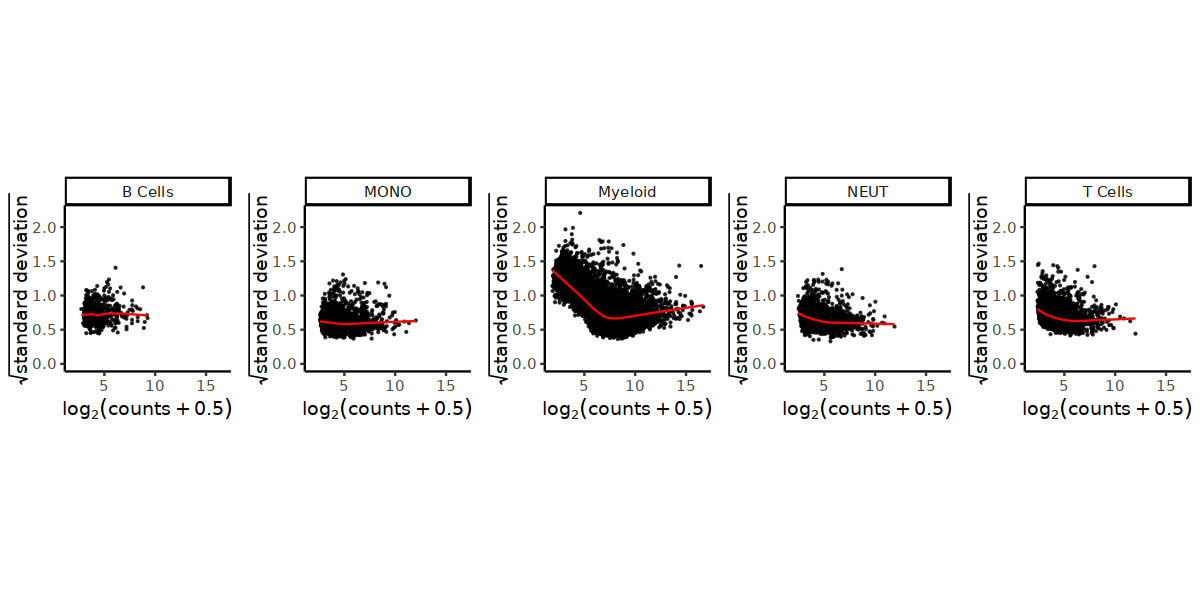

In [8]:
options(repr.plot.width=10, repr.plot.height=5)
my_VroomPlot(res.proc,ncol=5)+theme(text = element_text(size=30))

# Fit variance partition

In [9]:
rec.proc_subset <- res.proc[c(2,3,4,5)]
vp.lst <- fitVarPart(rec.proc_subset, ~ race +dx+sex + BL+TSH+ age +mRS_binned)

  MONO...
17 secs

  Myeloid...
1 mins

  NEUT...
15 secs

  T Cells...
22 secs






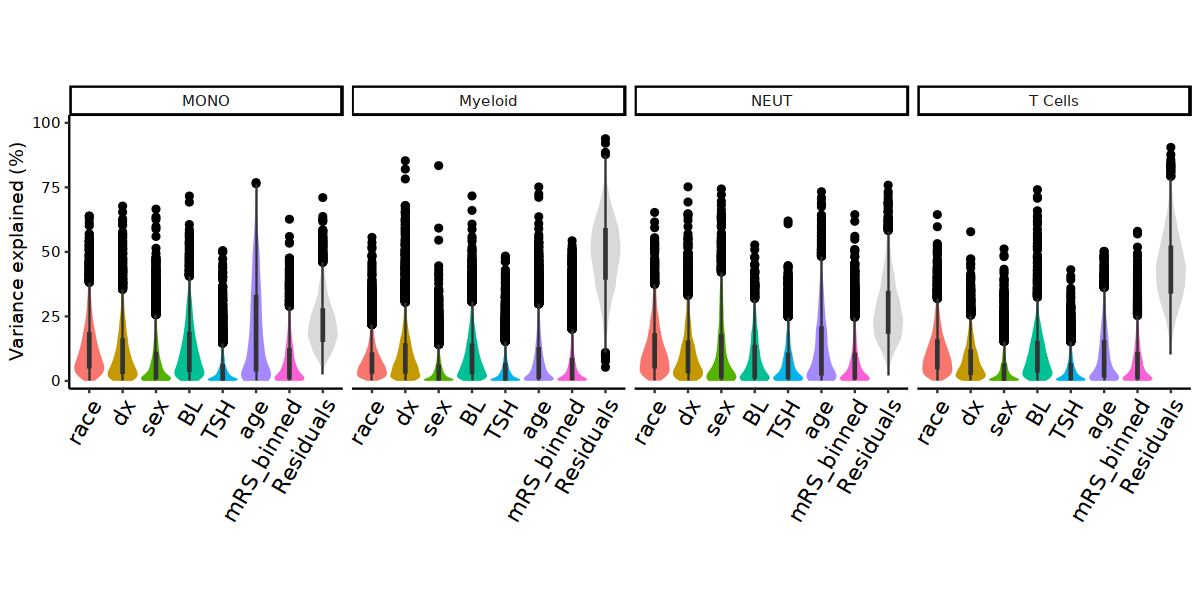

In [10]:
# Summarize variance fractions genome-wide for each cell type
plotVarPart(vp.lst, label.angle = 60,ncol=5)

# Run dreamlet

In [11]:
res.dream_mRS = dreamlet(rec.proc_subset, ~ (1|race)+ (1|dx)+ (1|BL)+age +mRS_binned+0,
                contrasts=c(Diff_B_vs_G="mRS_binnedB-mRS_binnedG"),
                BPPARAM = SnowParam(20, progressbar=TRUE))

  MONO...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


1.3 mins

  Myeloid...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


2.4 mins

  NEUT...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


1.2 mins

  T Cells...
iteration: 
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


1.4 mins






Warning message:
“Removed 11227 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 3344 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 2802 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 4184 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 13 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


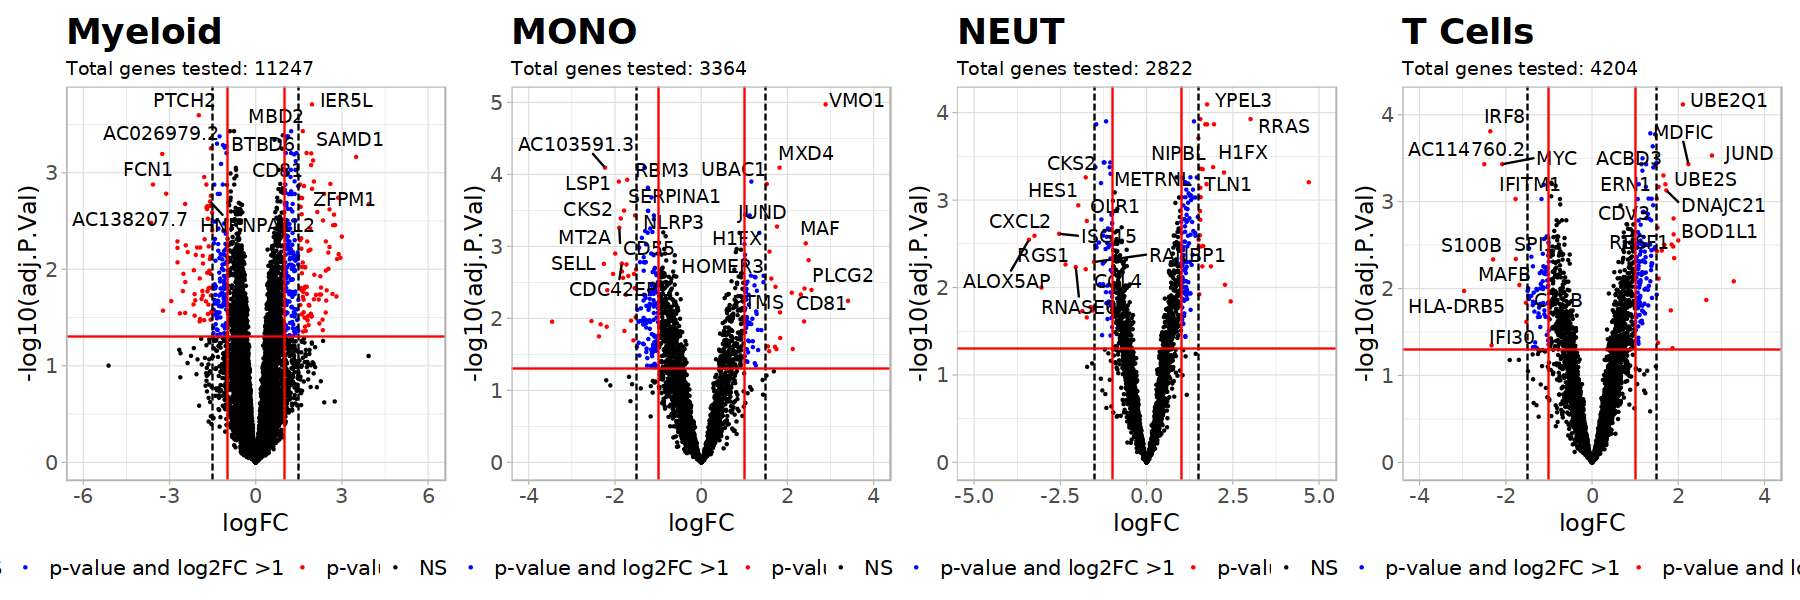

In [12]:
# Load the required library for enhanced label placement in ggplot2
library(ggrepel)

# Extract data for volcano plotting from the differential expression results
# Include all genes by setting p-value and log-fold change (lfc) thresholds to include everything
Vlcano_df <- as.data.frame(topTable(res.dream_mRS, 
                                    p.value = 1, 
                                    lfc = 0, 
                                    number = 100000000, 
                                    coef = "Diff_B_vs_G"))

# Sort the volcano data frame by adjusted p-value (adj.P.Val) in ascending order
Vlcano_df <- Vlcano_df[order(Vlcano_df$adj.P.Val), ]

# Rename the second column to 'gene.name' for better interpretation
colnames(Vlcano_df)[2] <- "gene.name"

# Add a new column 'diffexpressed' initialized as "NO" (indicating no differential expression)
Vlcano_df$diffexpressed <- "NO"

# Update 'diffexpressed' to "NS" (indicating non-significant expression)
# Note: This overwrites the previous "NO" value, which appears redundant
Vlcano_df$diffexpressed <- "NS"

# Define the first cell type for volcano plotting and generate the corresponding plot
cellType <- 'Myeloid'
p1 <- my_Vlc_plot(Vlcano_df, x_lim, cellType)  # 'my_Vlc_plot' is assumed to be a user-defined function

# Repeat for a second cell type, 'MONO', and create its plot
cellType <- 'MONO'
p2 <- my_Vlc_plot(Vlcano_df, x_lim, cellType)

# Repeat for a third cell type, 'NEUT', and create its plot
cellType <- 'NEUT'
p3 <- my_Vlc_plot(Vlcano_df, x_lim, cellType)

# Repeat for a fourth cell type, 'T Cells', and create its plot
cellType <- 'T Cells'
p4 <- my_Vlc_plot(Vlcano_df, x_lim, cellType)

# Set the plot dimensions for consistent output
options(repr.plot.width = 15, repr.plot.height = 5)

# Combine the individual volcano plots into a single plot arranged in 4 columns
p_volc <- p1 + p2 + p3 + p4 +
    plot_layout(ncol = 4)

# Display the combined volcano plot
p_volc


In [13]:
# Convert the result table from the differential expression analysis (res.dream_mRS)
# to a data frame and include all entries without filtering by p-value or log-fold change.
# Specify the coefficient of interest ("Diff_B_vs_G").
DEGs_file <- as.data.frame(topTable(res.dream_mRS,
    p.value = 1, lfc = 0, number = 100000000, coef = "Diff_B_vs_G"))

# Remove rows where the assay type is "B Cells" to exclude them from further analysis
DEGs_file <- DEGs_file %>% filter(assay != "B Cells")

# Sort the DEGs file by adjusted p-value (adj.P.Val) in ascending order for prioritization
DEGs_file <- DEGs_file[order(DEGs_file$adj.P.Val), ]

# Add a new column, 'diffexpressed', and initialize it to "NO" (indicating no differential expression)
DEGs_file$diffexpressed <- "NO"

# Update 'diffexpressed' to "NS" (indicating non-significant expression)
# (This step appears redundant as it overwrites the previous value)
DEGs_file$diffexpressed <- "NS"

# Add a new column 'cluster' to classify genes based on the sign of logFC
# Genes with positive logFC are labeled "Bad" and with negative logFC are labeled "Good"
DEGs_file$cluster <- ifelse(DEGs_file$logFC > 0, 'Bad', 'Good')

# Append the assay type to the cluster labels for more specific classification
DEGs_file$cluster <- paste0(DEGs_file$cluster, "_", DEGs_file$assay)

# Attempt to assign gene identifiers (ID) to a column 'gene' (but likely a typo with '<' instead of '<-')
# Corrected to assign 'ID' values to 'gene'
DEGs_file$gene <- DEGs_file$ID

# Create a background list of unique gene IDs from the DEGs file for potential downstream use
background <- unique(DEGs_file$ID)

# Group the DEGs file by gene ID and calculate the average logFC for positively expressed genes
# Store this in a new column 'pos_avgLFC'
DEGs_file <- DEGs_file %>% group_by(ID) %>% mutate(pos_avgLFC = mean(logFC))

# Group the DEGs file by gene ID and calculate the average logFC across unique assay types
# Store this in a new column 'avg_LFC'
DEGs_file <- DEGs_file %>% group_by(ID) %>% mutate(avg_LFC = sum(logFC) / length(unique(DEGs_file$assay)))


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


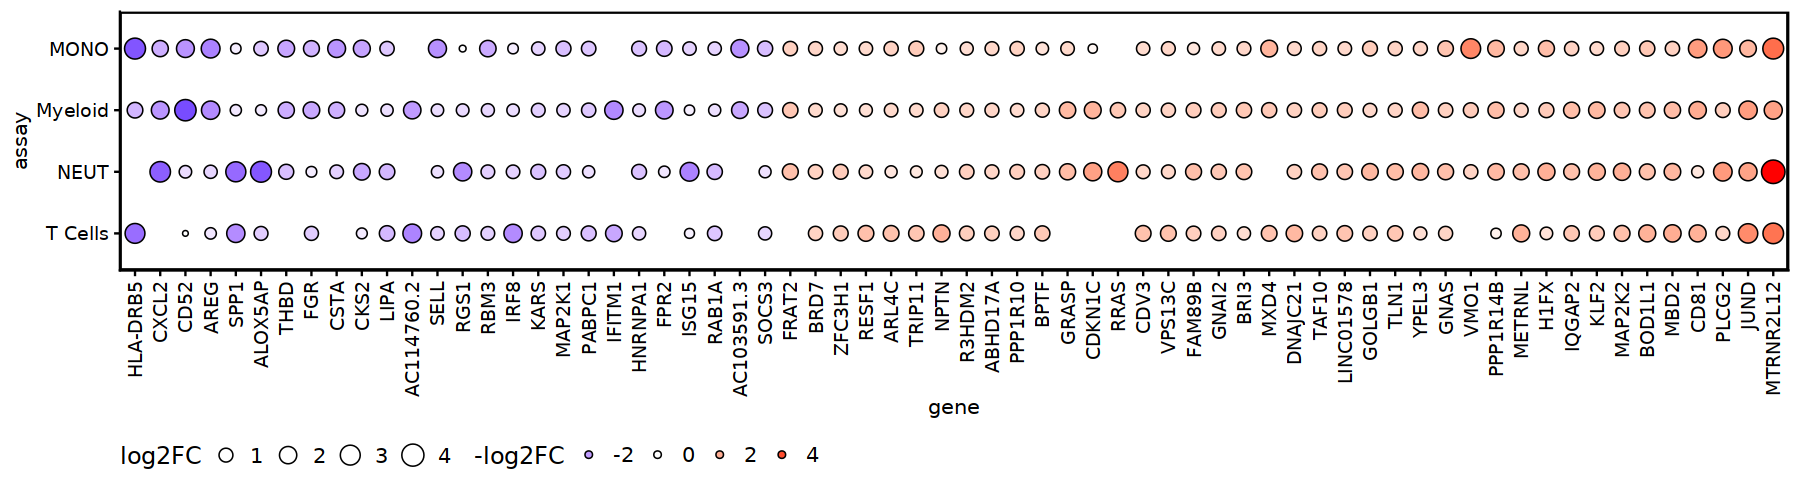

In [14]:
# Filter the DEGs_file to select significantly differentially expressed genes (DEGs)
# Criteria: adjusted p-value < 0.05 and absolute log-fold change (avg_LFC) > 1
sign_DEGS_df <- DEGs_file[DEGs_file$adj.P.Val < 0.05 & abs(DEGs_file$avg_LFC) > 1, ]

# Subset the data to include only rows corresponding to significant DEGs
# This uses the unique gene IDs from 'sign_DEGS_df'
data.plot <- DEGs_file[DEGs_file$ID %in% unique(as.factor(sign_DEGS_df$ID)), ]

# Remove any rows with missing values
data.plot <- data.plot %>% na.omit()

# Order the data by average log-fold change (avg_LFC) for consistent visualization
data.plot <- data.plot[order(data.plot$avg_LFC), ]

# Convert the 'ID' column into a factor to maintain the ordering in the plot
# Ensure that the levels of the factor match the order in 'data.plot'
data.plot$gene <- factor(as.vector(data.plot$ID), levels = unique(as.vector(data.plot$ID)))

# Define color gradient endpoints for plotting (blue for low, red for high)
cols = c("blue", "red")

# Convert 'assay' column into a factor and reverse-sort the levels
# This ensures consistent ordering in the plot
data.plot$assay <- factor(data.plot$assay, levels = rev(sort(unique(data.plot$assay))))

# Create the ggplot visualization
plot <- ggplot(data = data.plot, aes(x = gene, y = assay, size = abs(logFC), fill = logFC)) +
    geom_point(shape = 21, colour = "black") +  # Add points with black borders
    theme(axis.title.x = element_blank(), axis.title.y = element_blank()) +  # Remove axis titles
    guides(size = guide_legend(title = 'log2FC')) +  # Add a legend for point size
    guides(fill = guide_legend(title = '-log2FC')) +  # Add a legend for point fill color
    theme_cowplot() +  # Use a clean Cowplot theme
    theme(panel.border = element_rect(colour = "black", fill = NA, size = 1)) +  # Add a black border
    scale_fill_gradient2(low = cols[1], mid = 'white', high = cols[2]) +  # Set the fill color gradient
    theme(plot.title = element_text(hjust = 0.5),  # Center-align the plot title
          axis.text = element_text(size = 11),  # Adjust font size for axis tick labels
          axis.title = element_text(size = 12),  # Adjust font size for axis titles
          axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)) +  # Rotate x-axis labels for readability
    theme(legend.position = "bottom")  # Position the legend at the bottom

# Set the dimensions for plot display
options(repr.plot.width = 15, repr.plot.height = 4)

# Optionally save the plot to a PDF file (uncomment the lines below to enable)
pdf('Figure1_F.pdf', width = 15, height = 4)
plot  # Print the plot to the PDF
dev.off()  # Close the PDF device

# Display the plot
plot


# SessionInfo

In [15]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 9.4 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] ggrepel_0.9.3               ggpubr_0.6.0               
 [3] lubridate_1.9.2             forcats_1.0.0              
 [5] stringr_1.5.0               purrr_1.0.1      